# Lab 5: Decision Function Example

You have been given a dataset that represents a series of credit card transactions. You would like to be able to predict which ones are fradulent. Dataset is taken from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data and can also be found on D2L.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Import dataset and split into feature matrix and target vector. Are there any columns that should be removed?

In [2]:
data = pd.read_csv('creditcard.csv')
X = data.drop(columns=['Time','Class'])
y = data['Class']

X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [3]:
# Split data and train logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Split the dataset into training and validation sets (use 20% testing split and random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train a linear classifier - increase max_iter if needed
logreg = LogisticRegression(max_iter=1000)

logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_val)

In [4]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962



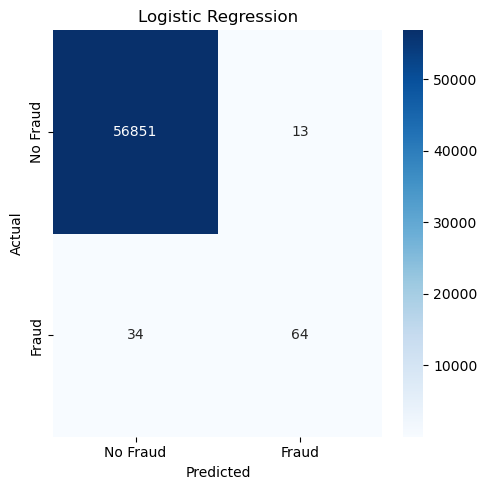

In [5]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm_lr = confusion_matrix(y_val, y_pred)

# Set up the figure suize using subplots
fig, axes = plt.subplots(figsize=(5, 5))

# Create a heatmap
sns.heatmap(cm_lr, xticklabels=['No Fraud', 'Fraud'],  yticklabels=['No Fraud', 'Fraud'],  annot=True, fmt='d', cmap='Blues', ax=axes)
axes.set_title('Logistic Regression')
axes.set_xlabel('Predicted')
axes.set_ylabel('Actual')

plt.tight_layout()
plt.show()


We would like to decrease the number of fraudulent cases that are predicted as "no fraud". How would we do this?

In this case, we want to decrease the number of false negatives (increase recall). To do this, we need to move the decision boundary towards the **negative region**.

In [6]:
from sklearn.metrics import classification_report
y_pred_lower_threshold = logreg.decision_function(X_val) > -3
print(classification_report(y_val, y_pred_lower_threshold))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.64      0.83      0.72        98

    accuracy                           1.00     56962
   macro avg       0.82      0.91      0.86     56962
weighted avg       1.00      1.00      1.00     56962



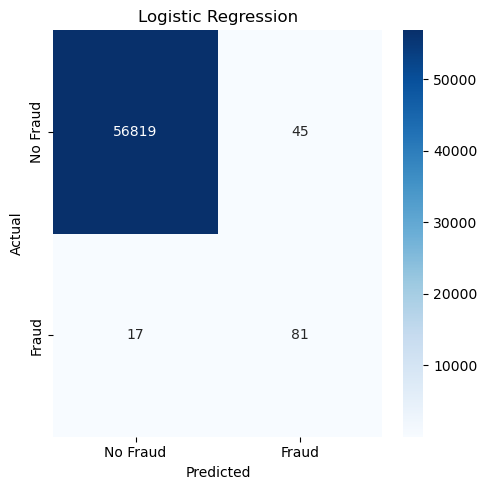

In [7]:
# Create confusion matrix
cm_lr = confusion_matrix(y_val, y_pred_lower_threshold)

# Set up the figure suize using subplots
fig, axes = plt.subplots(figsize=(5, 5))

# Create a heatmap
sns.heatmap(cm_lr, xticklabels=['No Fraud', 'Fraud'],  yticklabels=['No Fraud', 'Fraud'],  annot=True, fmt='d', cmap='Blues', ax=axes)
axes.set_title('Logistic Regression')
axes.set_xlabel('Predicted')
axes.set_ylabel('Actual')

plt.tight_layout()
plt.show()